# Forecasting Human Development and Measuring Regional Inequality in India

**Dataset:** GDL Subnational HDI Data (1990–2022) — 36 Indian States/UTs  



In [39]:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing


from sklearn.metrics import mean_absolute_error, mean_squared_error


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})



##  Data Preprocessing

In [40]:
raw = pd.read_csv("C:\\Users\\Nandana\\Downloads\\GDL-Subnational-HDI-data.csv")
print(f'Raw shape: {raw.shape}')
raw.head(3)

Raw shape: (37, 39)


,Country,Continent,ISO_Code,Level,GDLCODE,Region,1990,1991,1992,1993,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,India,Asia/Pacific,IND,National,INDt,Total,0.4340,0.4370,0.4420,0.4460,...,0.6000,0.6110,0.6190,0.6300,0.6360,0.6360,0.6380,0.6380,0.6330,0.6440
1,India,Asia/Pacific,IND,Subnat,INDr136,Andaman and Nicobar Islands,0.6860,0.6900,0.6970,0.6910,...,0.7000,0.7080,0.7140,0.7230,0.7180,0.7070,0.6990,0.6990,0.6930,0.7060
2,India,Asia/Pacific,IND,Subnat,INDr101,Andhra Pradesh,0.4280,0.4300,0.4350,0.4380,...,0.6020,0.6140,0.6230,0.6350,0.6380,0.6350,0.6350,0.6350,0.6300,0.6420


In [5]:
#   Separate National vs Subnational rows 
national = raw[raw['Level'] == 'National'].copy()
states   = raw[raw['Level'] == 'Subnat'].copy()

print(f'National rows : {len(national)}')
print(f'State/UT rows : {len(states)}')

National rows : 1
State/UT rows : 36


In [41]:
# Reshape to Long Format 
year_cols = [str(y) for y in range(1990, 2023)]   # columns 1990 … 2022

states_long = states.melt(
    id_vars=['Region', 'GDLCODE'],
    value_vars=year_cols,
    var_name='Year',
    value_name='HDI'
)
states_long['Year'] = states_long['Year'].astype(int)
states_long = states_long.sort_values(['Region', 'Year']).reset_index(drop=True)

# Missing Value Check 
missing = states_long['HDI'].isnull().sum()
print(f'Missing HDI values: {missing}')


states_long['HDI'] = states_long.groupby('Region')['HDI'].transform(
    lambda x: x.fillna(method='ffill').fillna(method='bfill')
)
print(f'Missing after fill : {states_long["HDI"].isnull().sum()}')
states_long.head()

Missing HDI values: 0
Missing after fill : 0


,Region,GDLCODE,Year,HDI
0,Andaman and Nicobar Islands,INDr136,1990,0.6860
1,Andaman and Nicobar Islands,INDr136,1991,0.6900
2,Andaman and Nicobar Islands,INDr136,1992,0.6970
3,Andaman and Nicobar Islands,INDr136,1993,0.6910
4,Andaman and Nicobar Islands,INDr136,1994,0.6880


In [42]:

#  National HDI time series 
national_series = national[year_cols].iloc[0].rename('HDI')
national_series.index = national_series.index.astype(int)
national_series.index.name = 'Year'

print('India National HDI (first & last 5 years):')
print(pd.concat([national_series.head(), national_series.tail()]))

India National HDI (first & last 5 years):
Year
1990   0.4340
1991   0.4370
1992   0.4420
1993   0.4460
1994   0.4520
2018   0.6360
2019   0.6380
2020   0.6380
2021   0.6330
2022   0.6440
Name: HDI, dtype: float64



## Exploratory Data Analysis (EDA)

In [43]:
# 2.1 Descriptive Statistics (latest year = 2022) 
latest = states_long[states_long['Year'] == 2022][['Region', 'HDI']]
print('=== HDI Summary Statistics (2022) ===')
print(latest['HDI'].describe().round(4))

=== HDI Summary Statistics (2022) ===
count   36.0000
mean     0.6739
std      0.0486
min      0.5770
25%      0.6325
50%      0.6800
75%      0.7098
max      0.7600
Name: HDI, dtype: float64


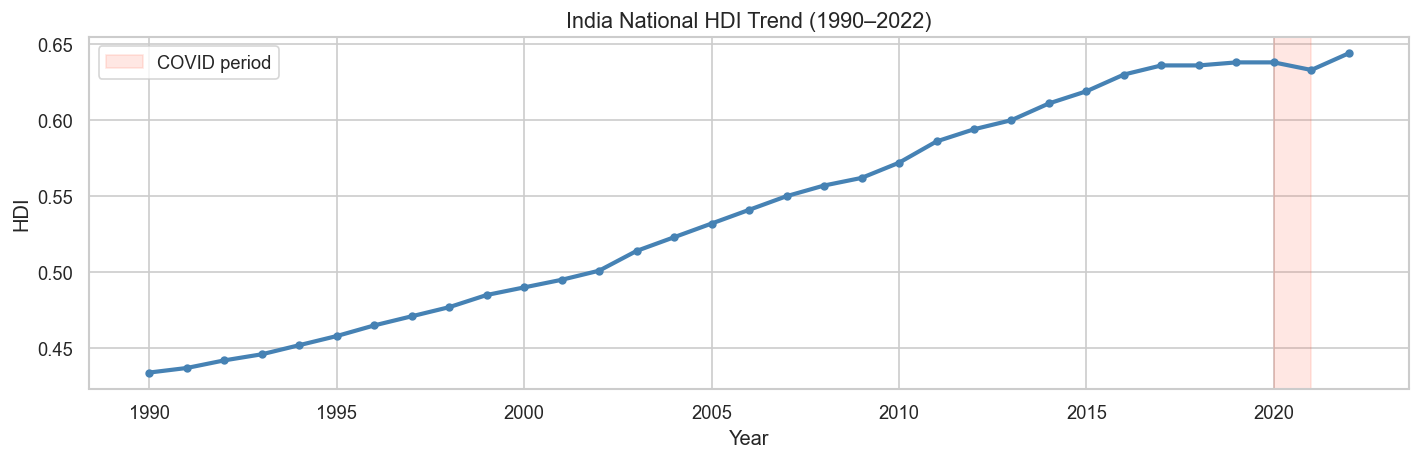

In [44]:
#  India's National HDI Trend 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(national_series.index, national_series.values,
        color='steelblue', linewidth=2.5, marker='o', markersize=4)
ax.axvspan(2020, 2021, color='tomato', alpha=0.15, label='COVID period')
ax.set_title('India National HDI Trend (1990–2022)')
ax.set_xlabel('Year')
ax.set_ylabel('HDI')
ax.legend()
plt.tight_layout()
plt.show()

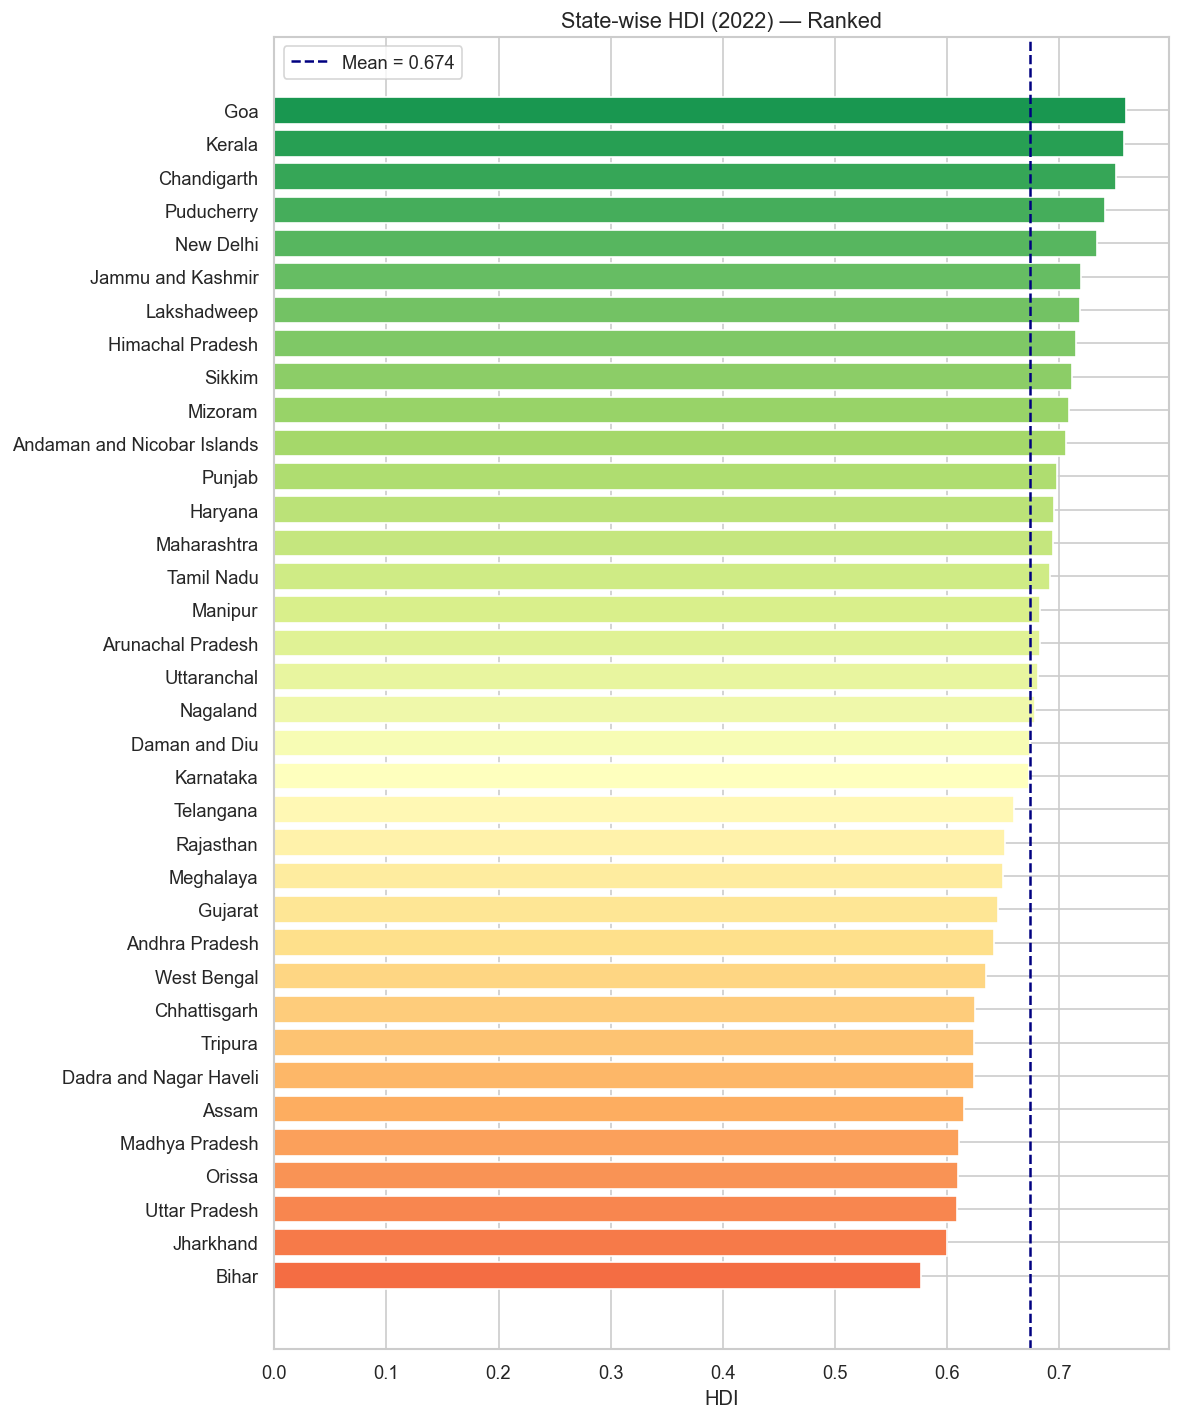

In [45]:
#  State-wise HDI in 2022  
latest_sorted = latest.sort_values('HDI', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(latest_sorted['Region'], latest_sorted['HDI'],
               color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(latest_sorted))))
ax.set_title('State-wise HDI (2022) — Ranked')
ax.set_xlabel('HDI')
ax.axvline(latest_sorted['HDI'].mean(), color='navy',
           linestyle='--', linewidth=1.5, label=f'Mean = {latest_sorted["HDI"].mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

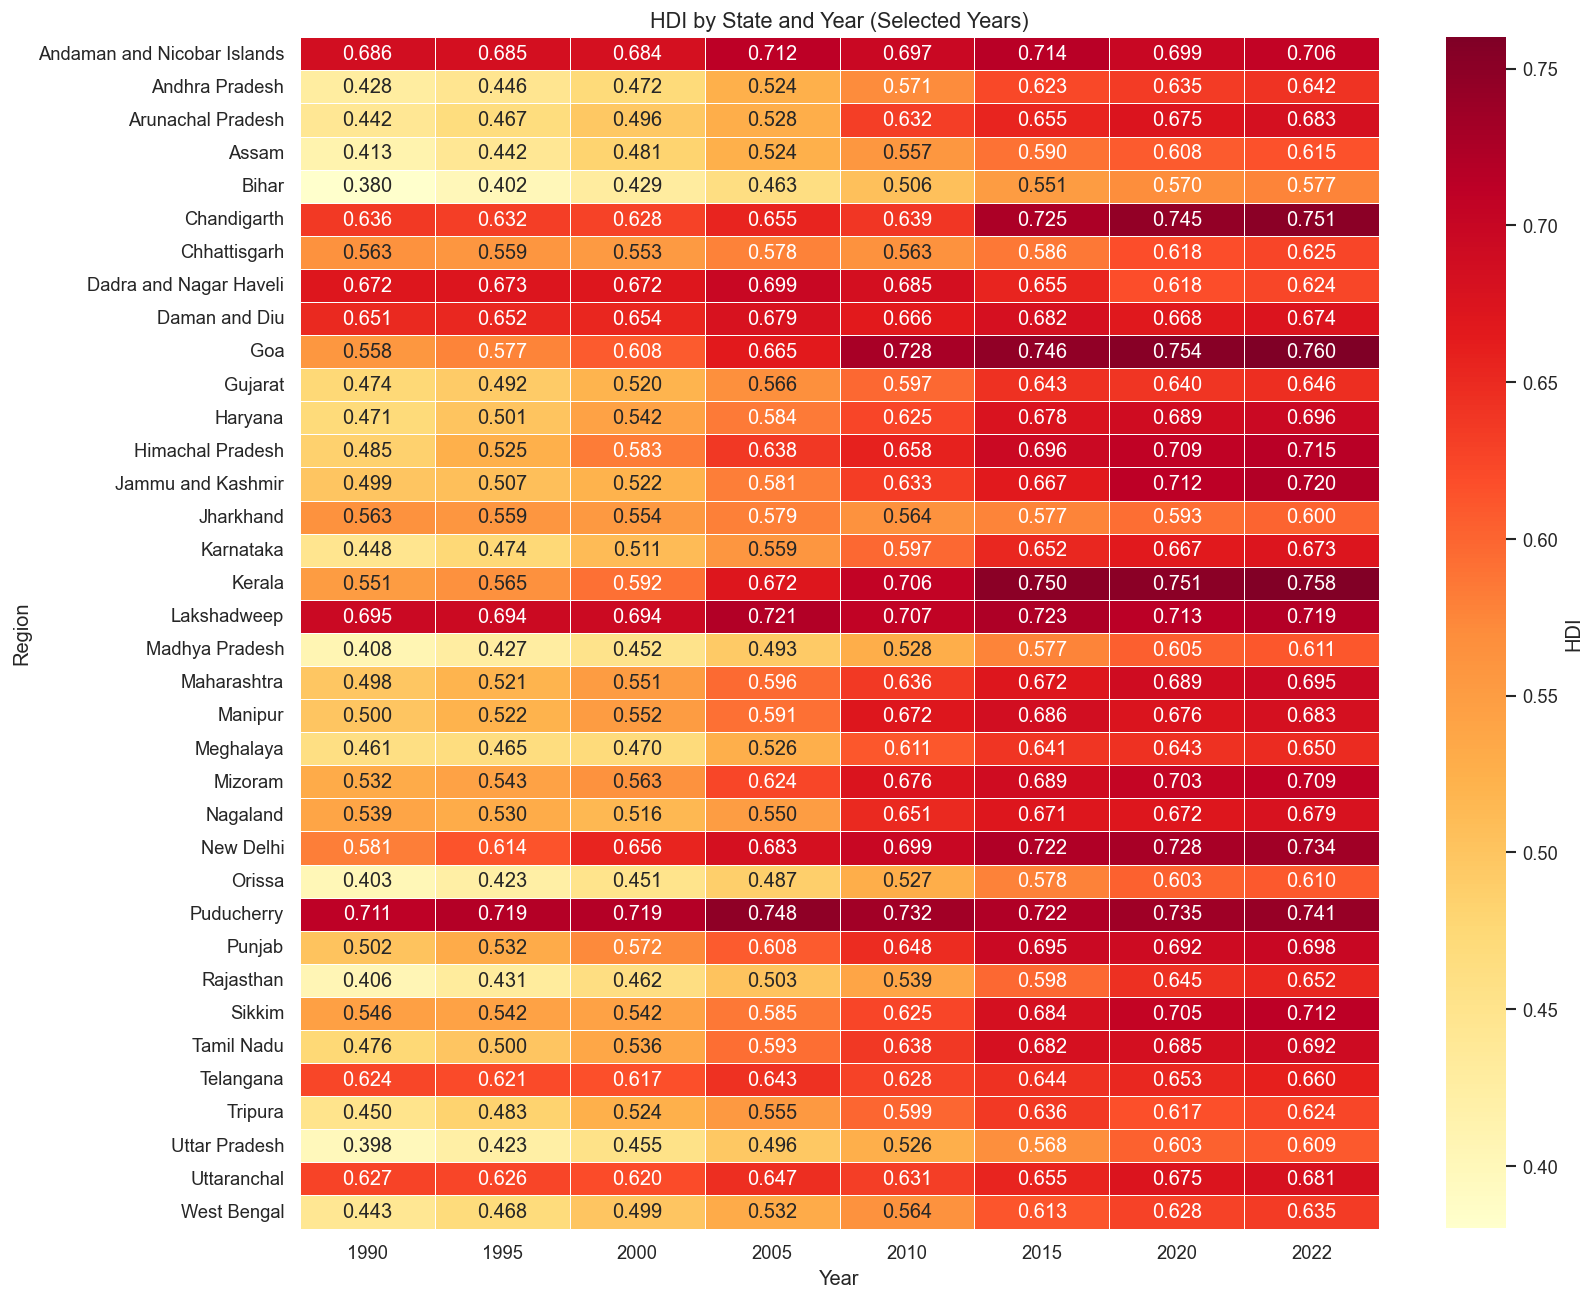

In [11]:
#  Heatmap: HDI by State × Year
pivot = states_long.pivot(index='Region', columns='Year', values='HDI')

# Show every 5 years to keep the plot readable
cols_to_show = [y for y in range(1990, 2023, 5)] + [2022]
pivot_sub = pivot[cols_to_show]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(pivot_sub, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'HDI'})
ax.set_title('HDI by State and Year (Selected Years)')
plt.tight_layout()
plt.show()

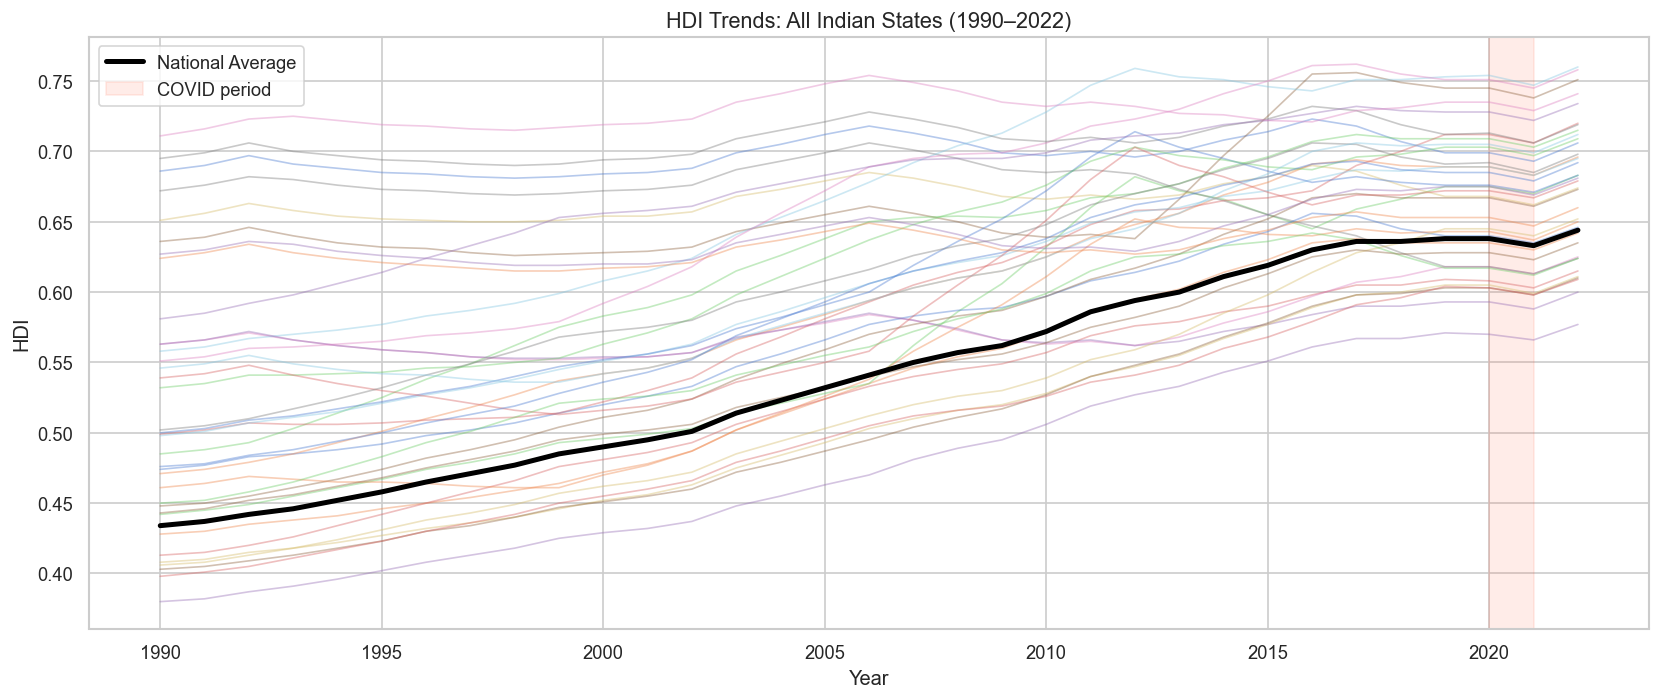

In [46]:
#  HDI Trend Lines for All States 
fig, ax = plt.subplots(figsize=(14, 6))

for region, grp in states_long.groupby('Region'):
    ax.plot(grp['Year'], grp['HDI'], alpha=0.4, linewidth=1)

# Overlay national average
ax.plot(national_series.index, national_series.values,
        color='black', linewidth=3, label='National Average')
ax.axvspan(2020, 2021, color='tomato', alpha=0.12, label='COVID period')
ax.set_title('HDI Trends: All Indian States (1990–2022)')
ax.set_xlabel('Year')
ax.set_ylabel('HDI')
ax.legend()
plt.tight_layout()
plt.show()

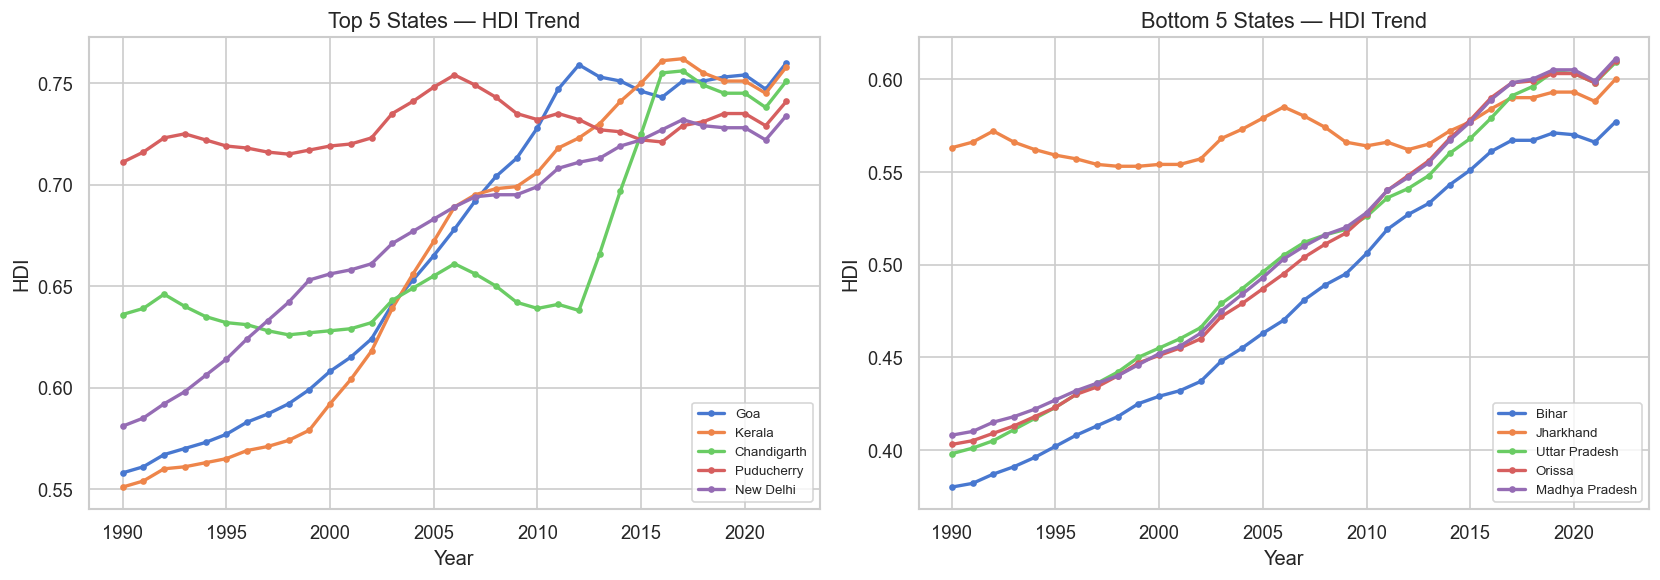

Top 5 States (2022):
     Region    HDI
        Goa 0.7600
     Kerala 0.7580
Chandigarth 0.7510
 Puducherry 0.7410
  New Delhi 0.7340

Bottom 5 States (2022):
        Region    HDI
         Bihar 0.5770
     Jharkhand 0.6000
 Uttar Pradesh 0.6090
        Orissa 0.6100
Madhya Pradesh 0.6110


In [47]:
#  Top 5 vs Bottom 5 States 
top5    = latest.nlargest(5,  'HDI')['Region'].tolist()
bottom5 = latest.nsmallest(5, 'HDI')['Region'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group, title, color in zip(
        axes,
        [top5, bottom5],
        ['Top 5 States — HDI Trend', 'Bottom 5 States — HDI Trend'],
        ['steelblue', 'tomato']):
    for region in group:
        d = states_long[states_long['Region'] == region]
        ax.plot(d['Year'], d['HDI'], marker='o', markersize=3,
                linewidth=2, label=region)
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('HDI')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Top 5 States (2022):')
print(latest.nlargest(5, 'HDI').to_string(index=False))
print('\nBottom 5 States (2022):')
print(latest.nsmallest(5, 'HDI').to_string(index=False))


##  Inequality Analysis — Gini Coefficient

In [48]:
# Gini Coefficient Function 
def gini_coefficient(values):
    """
    Compute the Gini coefficient from an array of values.
    Gini = 0  → perfect equality
    Gini = 1  → maximum inequality
    """
    values = np.array(sorted(values))
    n = len(values)
    cumulative = np.cumsum(values)
    gini = (2 * np.sum((np.arange(1, n + 1)) * values) / (n * cumulative[-1])) - (n + 1) / n
    return round(gini, 6)

In [49]:
# Gini per Year 
gini_by_year = (
    states_long
    .groupby('Year')['HDI']
    .apply(gini_coefficient)
    .reset_index(name='Gini')
)

print('Gini Coefficient over time (selected years):')
print(gini_by_year[gini_by_year['Year'].isin([1990, 2000, 2010, 2019, 2020, 2021, 2022])]
      .to_string(index=False))

Gini Coefficient over time (selected years):
 Year   Gini
 1990 0.1011
 2000 0.0773
 2010 0.0551
 2019 0.0411
 2020 0.0413
 2021 0.0412
 2022 0.0408


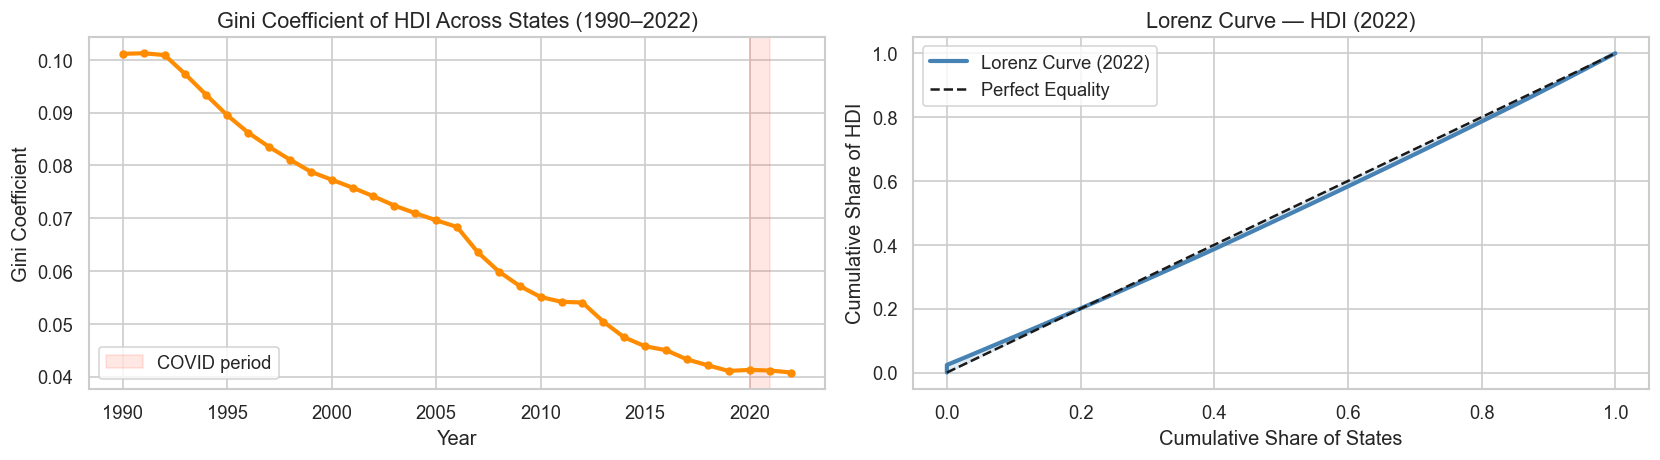


Gini 1990: 0.1011  |  Gini 2022: 0.0408
Change   : -0.0604 (decreased — inequality fell)


In [50]:
# Plot Gini Trend
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gini over time
ax = axes[0]
ax.plot(gini_by_year['Year'], gini_by_year['Gini'],
        color='darkorange', linewidth=2.5, marker='o', markersize=4)
ax.axvspan(2020, 2021, color='tomato', alpha=0.15, label='COVID period')
ax.set_title('Gini Coefficient of HDI Across States (1990–2022)')
ax.set_xlabel('Year')
ax.set_ylabel('Gini Coefficient')
ax.legend()

# Lorenz Curve for 2022
ax = axes[1]
vals_2022 = np.sort(states_long[states_long['Year'] == 2022]['HDI'].values)
lorenz_x = np.concatenate([[0], np.linspace(0, 1, len(vals_2022))])
lorenz_y = np.concatenate([[0], np.cumsum(vals_2022) / vals_2022.sum()])
ax.plot(lorenz_x, lorenz_y, color='steelblue', linewidth=2.5, label='Lorenz Curve (2022)')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Equality')
ax.fill_between(lorenz_x, lorenz_x, lorenz_y, alpha=0.15, color='steelblue')
ax.set_title('Lorenz Curve — HDI (2022)')
ax.set_xlabel('Cumulative Share of States')
ax.set_ylabel('Cumulative Share of HDI')
ax.legend()

plt.tight_layout()
plt.show()

g2022 = gini_by_year[gini_by_year['Year'] == 2022]['Gini'].values[0]
g1990 = gini_by_year[gini_by_year['Year'] == 1990]['Gini'].values[0]
print(f'\nGini 1990: {g1990:.4f}  |  Gini 2022: {g2022:.4f}')
print(f'Change   : {g2022 - g1990:+.4f} ({"decreased" if g2022 < g1990 else "increased"} — inequality {"fell" if g2022 < g1990 else "rose"})')

In [51]:
# Pre vs Post COVID Gini Comparison 
pre_covid  = gini_by_year[gini_by_year['Year'] == 2019]['Gini'].values[0]
covid_yr   = gini_by_year[gini_by_year['Year'] == 2020]['Gini'].values[0]
post_covid = gini_by_year[gini_by_year['Year'] == 2022]['Gini'].values[0]

print(f'Gini — Pre-COVID  (2019): {pre_covid:.4f}')
print(f'Gini — COVID year (2020): {covid_yr:.4f}')
print(f'Gini — Post-COVID (2022): {post_covid:.4f}')

Gini — Pre-COVID  (2019): 0.0411
Gini — COVID year (2020): 0.0413
Gini — Post-COVID (2022): 0.0408


---
##  Stationarity Testing (ADF, ACF, PACF)

In [52]:
# Augmented Dickey-Fuller (ADF) Test
def run_adf_test(series, name='Series'):
    """
    H0: data is non-stationary
    Reject H0 if p-value < 0.05 → data is stationary
    """
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- ADF Test: {name} ---')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical (1%) : {result[4]["1%"]:.4f}')
    print(f'  Critical (5%) : {result[4]["5%"]:.4f}')
    conclusion = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f'  Conclusion    : {conclusion}\n')
    return result[1]

In [53]:
# Test on National HDI (raw) 
p_raw = run_adf_test(national_series, name='National HDI (raw)')

# First difference
hdi_diff = national_series.diff().dropna()
p_diff   = run_adf_test(hdi_diff, name='National HDI (1st difference)')

--- ADF Test: National HDI (raw) ---
  ADF Statistic : -0.4977
  p-value       : 0.8925
  Critical (1%) : -3.6535
  Critical (5%) : -2.9572
  Conclusion    : NON-STATIONARY

--- ADF Test: National HDI (1st difference) ---
  ADF Statistic : -3.6008
  p-value       : 0.0057
  Critical (1%) : -3.6614
  Critical (5%) : -2.9605
  Conclusion    : STATIONARY



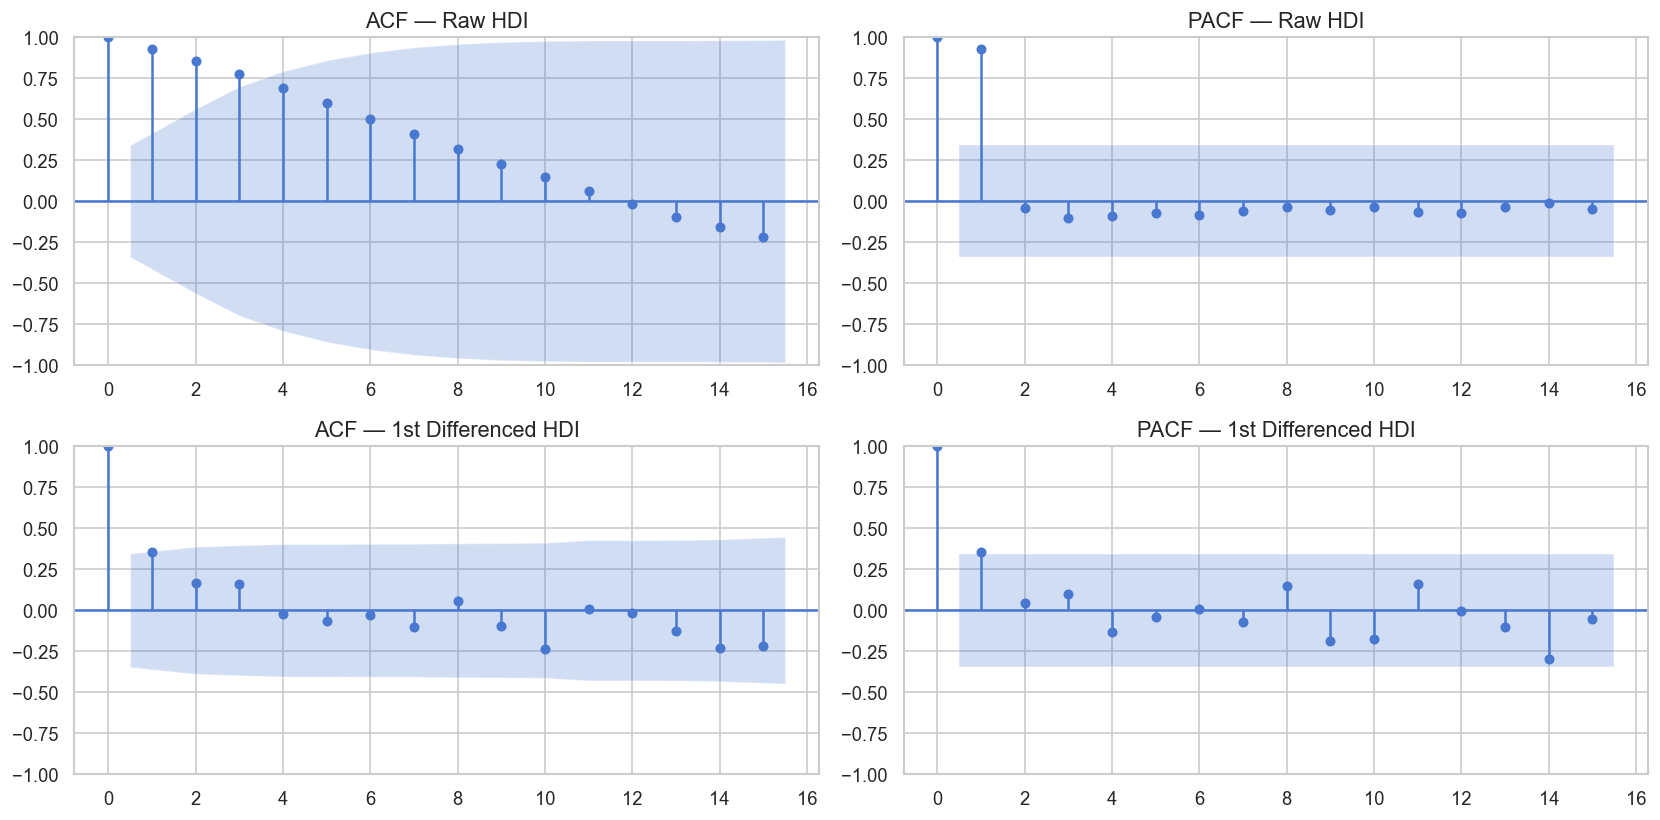

In [54]:
# ACF & PACF Plots 
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

plot_acf (national_series, lags=15, ax=axes[0, 0], title='ACF — Raw HDI')
plot_pacf(national_series, lags=15, ax=axes[0, 1], title='PACF — Raw HDI')
plot_acf (hdi_diff,        lags=15, ax=axes[1, 0], title='ACF — 1st Differenced HDI')
plot_pacf(hdi_diff,        lags=15, ax=axes[1, 1], title='PACF — 1st Differenced HDI')

plt.tight_layout()
plt.show()



## AIC-Based Order Identification

In [56]:
# Grid Search ARIMA(p,d,q) using AIC 
from itertools import product

def arima_aic_grid(series, p_range, d_range, q_range):
    
    results = []
    for p, d, q in product(p_range, d_range, q_range):
        try:
            model = ARIMA(series, order=(p, d, q)).fit()
            results.append({'p': p, 'd': d, 'q': q, 'AIC': round(model.aic, 2)})
        except Exception:
            pass   # skip non-convergent combinations
    aic_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    return aic_df

aic_table = arima_aic_grid(national_series,
                           p_range=range(0, 4),
                           d_range=range(0, 2),
                           q_range=range(0, 4))

print('\nTop 10 ARIMA orders by AIC:')
print(aic_table.head(10).to_string(index=False))

best_p, best_d, best_q = aic_table.iloc[0][['p', 'd', 'q']].astype(int)
print(f'\nBest ARIMA order: ({best_p}, {best_d}, {best_q})  AIC={aic_table.iloc[0]["AIC"]}')


Top 10 ARIMA orders by AIC:
 p  d  q       AIC
 1  1  1 -258.4000
 3  1  0 -257.1500
 2  0  1 -256.7800
 1  1  2 -256.1500
 2  1  0 -255.7300
 1  1  0 -255.2500
 3  1  1 -255.2000
 1  1  3 -254.9100
 2  0  2 -254.6300
 3  0  0 -253.9200

Best ARIMA order: (1, 1, 1)  AIC=-258.4


---
## Model Fitting & Comparison

Three models will be trained and compared:
1. **ARIMA** — best order from AIC grid
2. **SARIMA** — handles potential seasonal patterns
3. **Holt-Winters Exponential Smoothing** — classic benchmark

In [57]:
#  Train / Test Split 
# Use 1990–2017 for training, 2018–2022 for testing (5-year horizon)
train = national_series[national_series.index <= 2017]
test  = national_series[national_series.index >= 2018]

print(f'Training set: {train.index[0]}–{train.index[-1]}  ({len(train)} years)')
print(f'Test set    : {test.index[0]}–{test.index[-1]}   ({len(test)} years)')

Training set: 1990–2017  (28 years)
Test set    : 2018–2022   (5 years)


In [58]:
#  Model 1: ARIMA 
arima_model  = ARIMA(train, order=(best_p, best_d, best_q)).fit()
arima_fc     = arima_model.forecast(steps=len(test))
arima_fc.index = test.index

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                    HDI   No. Observations:                   28
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 120.940
Date:                Sat, 04 Apr 2026   AIC                           -235.880
Time:                        16:21:13   BIC                           -231.993
Sample:                             0   HQIC                          -234.724
                                 - 28                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9738      0.044     22.143      0.000       0.888       1.060
ma.L1         -0.5815      0.296     -1.962      0.050      -1.162      -0.001
sigma2      7.066e-06   1.95e-06      3.631      0.0

In [59]:
# Model 2: SARIMA(1,1,1)(0,0,1,5) 
# Annual data → modest seasonal period of 5 captures decade patterns
sarima_model = SARIMAX(train, order=(1, 1, 1),
                       seasonal_order=(0, 0, 1, 5)).fit(disp=False)
sarima_fc    = sarima_model.forecast(steps=len(test))
sarima_fc.index = test.index

print(sarima_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                               HDI   No. Observations:                   28
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 5)   Log Likelihood                 115.645
Date:                           Sat, 04 Apr 2026   AIC                           -223.290
Time:                                   16:21:25   BIC                           -218.107
Sample:                                        0   HQIC                          -221.749
                                            - 28                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5897      0.201      2.938      0.003       0.196       0.983
ma.L1          0.2375      0.276      0.860

In [60]:
# Model 3: Holt-Winters Exponential Smoothing 
hw_model = ExponentialSmoothing(
    train,
    trend='add',       # additive trend for steady growth
    seasonal=None      # no clear seasonality in annual data
).fit(optimized=True)

hw_fc = hw_model.forecast(steps=len(test))
hw_fc.index = test.index

print('Holt-Winters Parameters:')
print(f'  Alpha (level)  : {hw_model.params["smoothing_level"]:.4f}')
print(f'  Beta  (trend)  : {hw_model.params["smoothing_trend"]:.4f}')

Holt-Winters Parameters:
  Alpha (level)  : 0.9950
  Beta  (trend)  : 0.1895


In [61]:
# Model Evaluation: MAE, RMSE 
def evaluate_model(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': model_name, 'MAE': round(mae, 5),
            'RMSE': round(rmse, 5), 'MAPE (%)': round(mape, 3)}

scores = [
    evaluate_model(test, arima_fc,  f'ARIMA({best_p},{best_d},{best_q})'),
    evaluate_model(test, sarima_fc, 'SARIMA(1,1,1)(0,0,1,5)'),
    evaluate_model(test, hw_fc,     'Holt-Winters'),
]
scores_df = pd.DataFrame(scores)
print('\n===  Model Performance Comparison  ===')
print(scores_df.to_string(index=False))

best_model_name = scores_df.loc[scores_df['RMSE'].idxmin(), 'Model']
print(f'\n Best Model (lowest RMSE): {best_model_name}')


===  Model Performance Comparison  ===
                 Model    MAE   RMSE  MAPE (%)
          ARIMA(1,1,1) 0.0203 0.0223    3.1850
SARIMA(1,1,1)(0,0,1,5) 0.0115 0.0126    1.8060
          Holt-Winters 0.0238 0.0262    3.7290

 Best Model (lowest RMSE): SARIMA(1,1,1)(0,0,1,5)


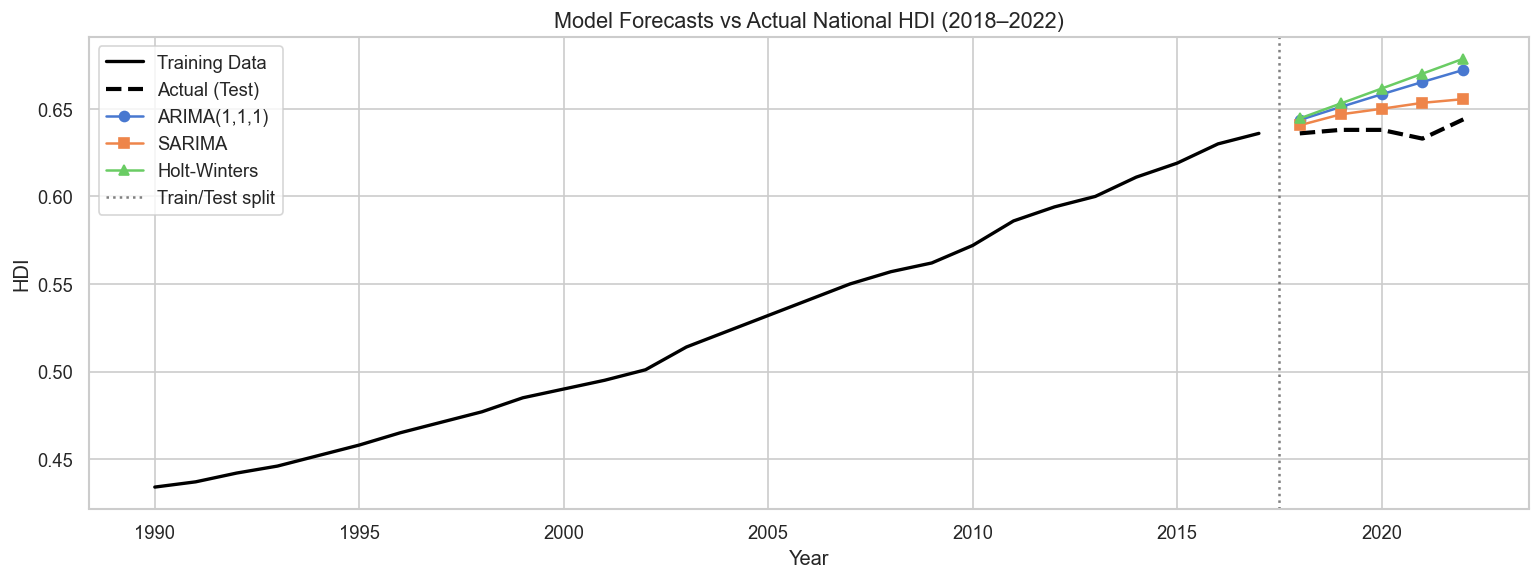

In [62]:
#  Forecast vs Actual Plot 
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train.index, train.values,
        color='black', linewidth=2, label='Training Data')
ax.plot(test.index, test.values,
        color='black', linewidth=2.5, linestyle='--', label='Actual (Test)')

ax.plot(arima_fc.index,  arima_fc.values,  marker='o', label=f'ARIMA({best_p},{best_d},{best_q})')
ax.plot(sarima_fc.index, sarima_fc.values, marker='s', label='SARIMA')
ax.plot(hw_fc.index,     hw_fc.values,     marker='^', label='Holt-Winters')

ax.axvline(2017.5, color='grey', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('Model Forecasts vs Actual National HDI (2018–2022)')
ax.set_xlabel('Year')
ax.set_ylabel('HDI')
ax.legend()
plt.tight_layout()
plt.show()

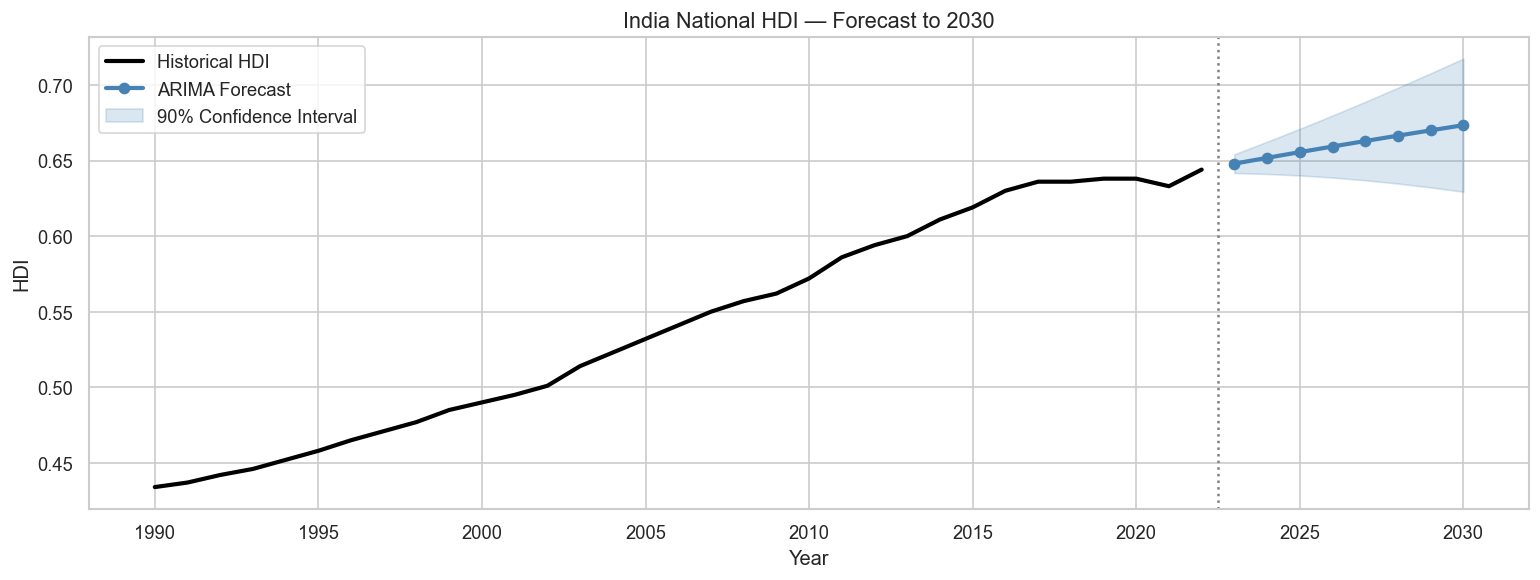


Forecasted HDI (2023–2030):
  2023: 0.6479
  2024: 0.6518
  2025: 0.6556
  2026: 0.6593
  2027: 0.6629
  2028: 0.6665
  2029: 0.6700
  2030: 0.6734


In [63]:
# Future Forecast: 2023–2030 (using full data) 
FORECAST_YEARS = 8   # 2023–2030
future_years   = list(range(2023, 2023 + FORECAST_YEARS))

# Refit ARIMA on full series
best_arima_full = ARIMA(national_series, order=(best_p, best_d, best_q)).fit()
future_fc       = best_arima_full.forecast(steps=FORECAST_YEARS)
ci              = best_arima_full.get_forecast(steps=FORECAST_YEARS).conf_int(alpha=0.10)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(national_series.index, national_series.values,
        color='black', linewidth=2.5, label='Historical HDI')
ax.plot(future_years, future_fc.values,
        color='steelblue', linewidth=2.5, marker='o', label='ARIMA Forecast')
ax.fill_between(future_years, ci.iloc[:, 0], ci.iloc[:, 1],
                alpha=0.2, color='steelblue', label='90% Confidence Interval')
ax.axvline(2022.5, color='grey', linestyle=':', linewidth=1.5)
ax.set_title('India National HDI — Forecast to 2030')
ax.set_xlabel('Year')
ax.set_ylabel('HDI')
ax.legend()
plt.tight_layout()
plt.show()

print('\nForecasted HDI (2023–2030):')
for yr, val in zip(future_years, future_fc.values):
    print(f'  {yr}: {val:.4f}')


## COVID Counterfactual Analysis

We estimate what HDI *would have been* in 2020–2022 without COVID by  
fitting an ARIMA model on **pre-COVID data (1990–2019)** and projecting forward.

In [30]:
# Fit Pre-COVID Model 
pre_covid_series = national_series[national_series.index <= 2019]
covid_actual     = national_series[national_series.index >= 2020]

cf_model = ARIMA(pre_covid_series, order=(best_p, best_d, best_q)).fit()
cf_fc    = cf_model.forecast(steps=3)   # 2020, 2021, 2022
cf_fc.index = [2020, 2021, 2022]

print('Counterfactual (No-COVID) vs Actual HDI:')
cf_compare = pd.DataFrame({
    'Year'            : [2020, 2021, 2022],
    'Actual HDI'      : covid_actual.values,
    'Counterfactual'  : cf_fc.values,
    'HDI Loss (gap)'  : cf_fc.values - covid_actual.values
})
print(cf_compare.to_string(index=False))
total_loss = cf_compare['HDI Loss (gap)'].sum()
print(f'\nCumulative HDI loss (2020–2022): {total_loss:.4f}')

Counterfactual (No-COVID) vs Actual HDI:
 Year  Actual HDI  Counterfactual  HDI Loss (gap)
 2020      0.6380          0.6398          0.0018
 2021      0.6330          0.6416          0.0086
 2022      0.6440          0.6433         -0.0007

Cumulative HDI loss (2020–2022): 0.0097


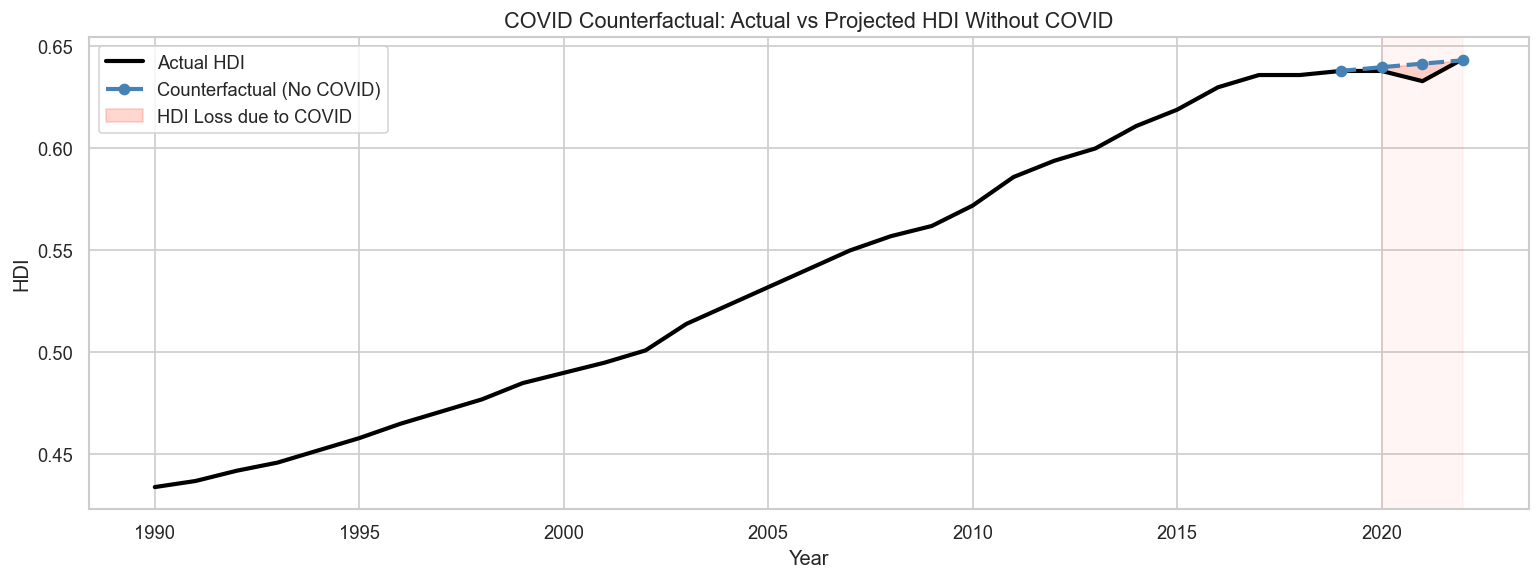

In [31]:
#  Plot Counterfactual 
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(national_series.index, national_series.values,
        color='black', linewidth=2.5, label='Actual HDI')
ax.plot([2019, 2020, 2021, 2022],
        [pre_covid_series[2019]] + cf_fc.tolist(),
        color='steelblue', linewidth=2.5, linestyle='--',
        marker='o', label='Counterfactual (No COVID)')

# Shade the gap
ax.fill_between([2020, 2021, 2022],
                covid_actual.values,
                cf_fc.values,
                alpha=0.25, color='tomato', label='HDI Loss due to COVID')

ax.axvspan(2020, 2022, color='tomato', alpha=0.06)
ax.set_title('COVID Counterfactual: Actual vs Projected HDI Without COVID')
ax.set_xlabel('Year')
ax.set_ylabel('HDI')
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
#  State-level COVID Impact (2019 vs 2021 HDI drop) 
hdi_2019 = states_long[states_long['Year'] == 2019][['Region', 'HDI']].rename(columns={'HDI': 'HDI_2019'})
hdi_2021 = states_long[states_long['Year'] == 2021][['Region', 'HDI']].rename(columns={'HDI': 'HDI_2021'})
hdi_2022 = states_long[states_long['Year'] == 2022][['Region', 'HDI']].rename(columns={'HDI': 'HDI_2022'})

covid_impact = hdi_2019.merge(hdi_2021, on='Region').merge(hdi_2022, on='Region')
covid_impact['COVID_drop']    = covid_impact['HDI_2019'] - covid_impact['HDI_2021']
covid_impact['Recovery_2022'] = covid_impact['HDI_2022'] - covid_impact['HDI_2021']
covid_impact = covid_impact.sort_values('COVID_drop', ascending=False)

print('States most impacted by COVID (HDI 2019→2021 drop):')
print(covid_impact[['Region', 'HDI_2019', 'HDI_2021', 'COVID_drop']]
      .head(10).to_string(index=False))

States most impacted by COVID (HDI 2019→2021 drop):
                     Region  HDI_2019  HDI_2021  COVID_drop
                Chandigarth    0.7450    0.7380      0.0070
Andaman and Nicobar Islands    0.6990    0.6930      0.0060
                  Karnataka    0.6670    0.6610      0.0060
                Uttaranchal    0.6750    0.6690      0.0060
              Uttar Pradesh    0.6040    0.5980      0.0060
                  Telangana    0.6530    0.6470      0.0060
                 Tamil Nadu    0.6850    0.6790      0.0060
                     Sikkim    0.7050    0.6990      0.0060
                 Puducherry    0.7350    0.7290      0.0060
                  New Delhi    0.7280    0.7220      0.0060


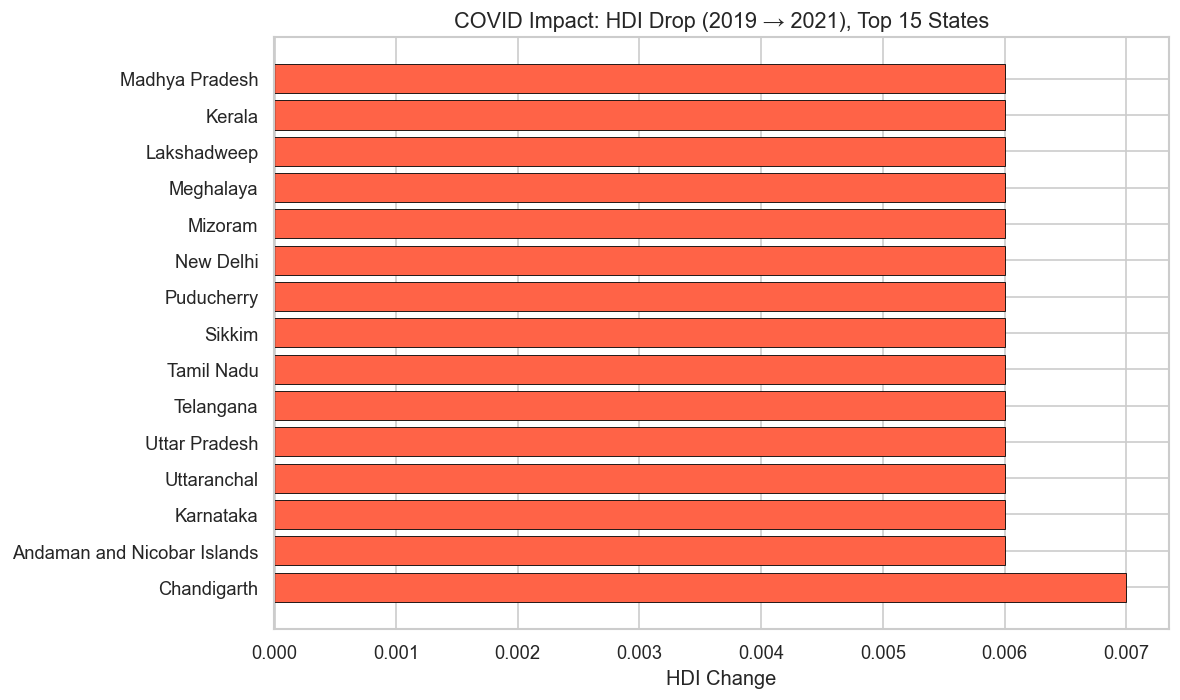

In [33]:
#  COVID Impact Plot 
top_impacted = covid_impact.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if d > 0 else 'steelblue' for d in top_impacted['COVID_drop']]
ax.barh(top_impacted['Region'], top_impacted['COVID_drop'],
        color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('COVID Impact: HDI Drop (2019 → 2021), Top 15 States')
ax.set_xlabel('HDI Change')
plt.tight_layout()
plt.show()


## Policy Insights

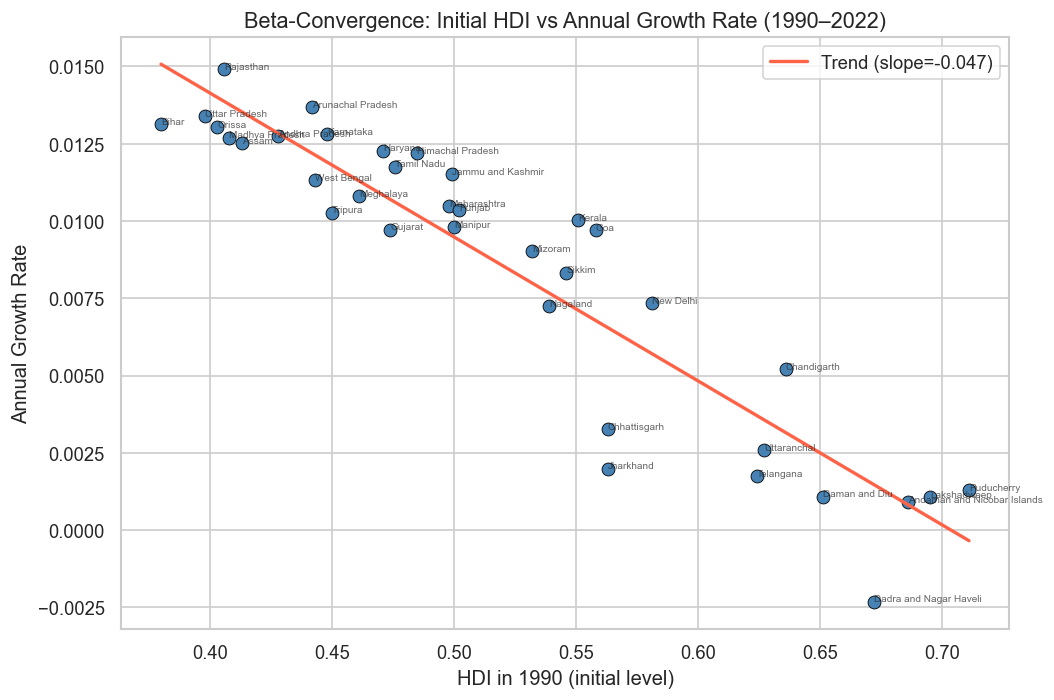

CONVERGENCE detected: States with lower initial HDI grew faster.


In [64]:
# Beta-Convergence: Are Poor States Catching Up? 
# Scatter: initial HDI (1990) vs growth rate → negative slope = convergence
hdi_1990 = states_long[states_long['Year'] == 1990][['Region', 'HDI']].rename(columns={'HDI': 'HDI_1990'})
hdi_2022 = states_long[states_long['Year'] == 2022][['Region', 'HDI']].rename(columns={'HDI': 'HDI_2022'})

conv_df = hdi_1990.merge(hdi_2022, on='Region')
conv_df['growth_rate'] = (conv_df['HDI_2022'] / conv_df['HDI_1990']) ** (1/32) - 1

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(conv_df['HDI_1990'], conv_df['growth_rate'],
           color='steelblue', s=60, edgecolor='black', linewidth=0.5)

for _, row in conv_df.iterrows():
    ax.annotate(row['Region'], (row['HDI_1990'], row['growth_rate']),
                fontsize=6, alpha=0.7, ha='left')

# OLS trend line
m = np.polyfit(conv_df['HDI_1990'], conv_df['growth_rate'], 1)
x_line = np.linspace(conv_df['HDI_1990'].min(), conv_df['HDI_1990'].max(), 100)
ax.plot(x_line, np.polyval(m, x_line), color='tomato', linewidth=2,
        label=f'Trend (slope={m[0]:.3f})')
ax.set_title('Beta-Convergence: Initial HDI vs Annual Growth Rate (1990–2022)')
ax.set_xlabel('HDI in 1990 (initial level)')
ax.set_ylabel('Annual Growth Rate')
ax.legend()
plt.tight_layout()
plt.show()

if m[0] < 0:
    print('CONVERGENCE detected: States with lower initial HDI grew faster.')
else:
    print('DIVERGENCE detected: States with higher initial HDI grew faster.')

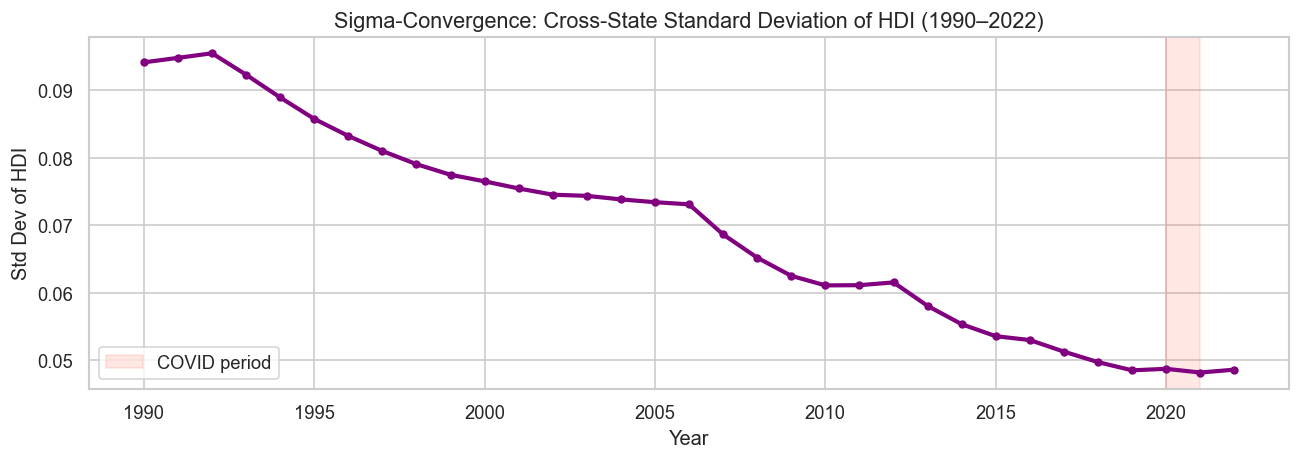

Std Dev 1990: 0.0941  |  Std Dev 2022: 0.0486
Dispersion has DECREASED → sigma convergence confirmed


In [35]:
# ── 8.2 Sigma Convergence: Standard Deviation of HDI Over Time ───────────────
std_by_year = states_long.groupby('Year')['HDI'].std().reset_index(name='STD')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(std_by_year['Year'], std_by_year['STD'],
        color='purple', linewidth=2.5, marker='o', markersize=4)
ax.axvspan(2020, 2021, color='tomato', alpha=0.15, label='COVID period')
ax.set_title('Sigma-Convergence: Cross-State Standard Deviation of HDI (1990–2022)')
ax.set_xlabel('Year')
ax.set_ylabel('Std Dev of HDI')
ax.legend()
plt.tight_layout()
plt.show()

std_1990 = std_by_year[std_by_year['Year'] == 1990]['STD'].values[0]
std_2022 = std_by_year[std_by_year['Year'] == 2022]['STD'].values[0]
print(f'Std Dev 1990: {std_1990:.4f}  |  Std Dev 2022: {std_2022:.4f}')
print('Dispersion has', 'DECREASED' if std_2022 < std_1990 else 'INCREASED',
      '→ sigma convergence', 'confirmed' if std_2022 < std_1990 else 'NOT confirmed')

In [65]:
# Identify Persistently Lagging States 
mean_hdi_by_state = states_long.groupby('Region')['HDI'].mean().sort_values()
national_avg = states_long['HDI'].mean()

laggards = mean_hdi_by_state[mean_hdi_by_state < national_avg].index.tolist()

print(f'States BELOW national average HDI (1990–2022 mean = {national_avg:.3f}):')
for s in laggards:
    print(f'  {s:<30} avg HDI = {mean_hdi_by_state[s]:.4f}')

States BELOW national average HDI (1990–2022 mean = 0.598):
  Bihar                          avg HDI = 0.4775
  Uttar Pradesh                  avg HDI = 0.5020
  Orissa                         avg HDI = 0.5022
  Madhya Pradesh                 avg HDI = 0.5045
  Rajasthan                      avg HDI = 0.5188
  Assam                          avg HDI = 0.5234
  Andhra Pradesh                 avg HDI = 0.5351
  West Bengal                    avg HDI = 0.5414
  Meghalaya                      avg HDI = 0.5517
  Tripura                        avg HDI = 0.5589
  Arunachal Pradesh              avg HDI = 0.5648
  Karnataka                      avg HDI = 0.5652
  Gujarat                        avg HDI = 0.5678
  Jharkhand                      avg HDI = 0.5709
  Chhattisgarh                   avg HDI = 0.5757
  Haryana                        avg HDI = 0.5918
  Tamil Nadu                     avg HDI = 0.5946
  Nagaland                       avg HDI = 0.5951
  Jammu and Kashmir              avg HDI

In [66]:

# POLICY INSIGHT — State-wise HDI Tier Classification & Forecast


import warnings
warnings.filterwarnings('ignore')

# Forecast 2030 HDI for each state using ARIMA(1,1,1) 
from statsmodels.tsa.arima.model import ARIMA

FORECAST_HORIZON = 8          # 2023 → 2030
TARGET_YEAR      = 2030
THRESHOLD_HIGH   = 0.70       # "High Human Development" benchmark
THRESHOLD_LOW    = 0.65       # "Urgent intervention" benchmark

records = []

for region, grp in states_long.groupby('Region'):
    series = grp.set_index('Year')['HDI'].sort_index()

    try:
        model = ARIMA(series, order=(1, 1, 1)).fit()
        fc    = model.forecast(steps=FORECAST_HORIZON)
        hdi30 = fc.iloc[-1]          # value at 2030
    except Exception:
        # Fallback: linear extrapolation if ARIMA fails
        slope = (series.iloc[-1] - series.iloc[-5]) / 5
        hdi30 = series.iloc[-1] + slope * FORECAST_HORIZON

    records.append({
        'name'  : region,
        'hdi22' : round(series[2022], 4),
        'hdi30' : round(hdi30,        4),
        'growth': round(hdi30 - series[2022], 4)
    })

# Classify states into policy tiers 
will_cross  = [r for r in records if r['hdi22'] < THRESHOLD_HIGH
                                  and r['hdi30'] >= THRESHOLD_HIGH]

still_below = [r for r in records if r['hdi30'] < THRESHOLD_LOW]

already_hi  = [r for r in records if r['hdi22'] >= THRESHOLD_HIGH]

on_track    = [r for r in records if r['hdi22'] < THRESHOLD_HIGH
                                  and r['hdi30'] < THRESHOLD_HIGH
                                  and r['hdi30'] >= THRESHOLD_LOW]

#  Print Policy Insights 
DIVIDER = "─" * 62

def print_section(title, icon):
    print(f"\n╔{'═' * 60}╗")
    print(f"║  {icon}  {title:<55}║")
    print(f"╚{'═' * 60}╝")

# INSIGHT 1: Will cross 0.70 by 2030 
print_section("STATES CROSSING HDI 0.70 BY 2030", "✦")
print(f"  {'State':<28} {'HDI 2022':>10} {'HDI 2030':>10} {'Gain':>8}")
print(f"  {DIVIDER}")
for r in sorted(will_cross, key=lambda x: x['hdi30'], reverse=True):
    print(f"  ✓  {r['name']:<25} {r['hdi22']:>10.3f} {r['hdi30']:>10.3f} {r['growth']:>+8.3f}")
print(f"\n  → {len(will_cross)} state(s) will join High Human Development by 2030.")

# ── INSIGHT 2: Still below 0.65 in 2030 — urgent ─────────────────────────────
print_section("STATES STILL BELOW 0.65 IN 2030  (URGENT)", "⚑")
print(f"  {'State':<28} {'HDI 2030':>10} {'Gap to 0.65':>12}")
print(f"  {DIVIDER}")
for r in sorted(still_below, key=lambda x: x['hdi30']):
    gap = THRESHOLD_LOW - r['hdi30']
    print(f"  ✗  {r['name']:<25} {r['hdi30']:>10.3f} {gap:>+12.3f}")
print(f"\n  → {len(still_below)} state(s) need urgent policy intervention.")

# ── INSIGHT 3: Already high HDI — maintain momentum ───────────────────────────
print_section("ALREADY HIGH HDI STATES  (MAINTAIN MOMENTUM)", "★")
print(f"  {'State':<28} {'HDI 2022':>10} {'HDI 2030':>10} {'Gain':>8}")
print(f"  {DIVIDER}")
for r in sorted(already_hi, key=lambda x: x['hdi22'], reverse=True):
    print(f"  ★  {r['name']:<25} {r['hdi22']:>10.3f} {r['hdi30']:>10.3f} {r['growth']:>+8.3f}")
print(f"\n  → {len(already_hi)} state(s) already above 0.70 — focus on quality & equity.")

#  INSIGHT 4: On track but needs support 
print_section("ON TRACK  (0.65–0.70 by 2030, needs support)", "◈")
print(f"  {'State':<28} {'HDI 2022':>10} {'HDI 2030':>10} {'Gain':>8}")
print(f"  {DIVIDER}")
for r in sorted(on_track, key=lambda x: x['hdi30'], reverse=True):
    print(f"  ◈  {r['name']:<25} {r['hdi22']:>10.3f} {r['hdi30']:>10.3f} {r['growth']:>+8.3f}")
print(f"\n  → {len(on_track)} state(s) are progressing — targeted support can accelerate.")

# INSIGHT 5: Summary statistics 
print(f"\n{'═' * 62}")
print("  NATIONAL SUMMARY")
print(f"{'═' * 62}")
avg_hdi22 = sum(r['hdi22'] for r in records) / len(records)
avg_hdi30 = sum(r['hdi30'] for r in records) / len(records)
avg_gain  = avg_hdi30 - avg_hdi22
print(f"  Average state HDI  2022 : {avg_hdi22:.4f}")
print(f"  Average state HDI  2030 : {avg_hdi30:.4f}")
print(f"  Average projected gain  : {avg_gain:+.4f}")
print(f"  Tier breakdown:")
print(f"    ★ Already High (≥0.70 in 2022) : {len(already_hi):>3} states")
print(f"    ✓ Will Cross   (≥0.70 by 2030) : {len(will_cross):>3} states")
print(f"    ◈ On Track     (0.65–0.70)     : {len(on_track):>3} states")
print(f"    ✗ Urgent       (<0.65 in 2030) : {len(still_below):>3} states")
print(f"{'═' * 62}")


╔════════════════════════════════════════════════════════════╗
║  ✦  STATES CROSSING HDI 0.70 BY 2030                       ║
╚════════════════════════════════════════════════════════════╝
  State                          HDI 2022   HDI 2030     Gain
  ──────────────────────────────────────────────────────────────
  ✓  Punjab                         0.698      0.728   +0.030
  ✓  Haryana                        0.696      0.725   +0.029
  ✓  Maharashtra                    0.695      0.722   +0.027
  ✓  Tamil Nadu                     0.692      0.719   +0.027
  ✓  Manipur                        0.683      0.716   +0.033
  ✓  Arunachal Pradesh              0.683      0.715   +0.032
  ✓  Nagaland                       0.679      0.710   +0.031
  ✓  Karnataka                      0.673      0.709   +0.036

  → 8 state(s) will join High Human Development by 2030.

╔════════════════════════════════════════════════════════════╗
║  ⚑  STATES STILL BELOW 0.65 IN 2030  (URGENT)              ║
╚═